# ML - Supervised Learning
## Random Forest
**Problem Statement: Build a simple Random Forest model using the Titanic dataset to predict whether a passenger survived or did not survive based on their Pclass, Sex, Age, and Fare.**

In [1]:
# Import the libraries
import numpy as np
import pandas as pd

In [2]:
# Load dataset
df = pd.read_csv("titanic_dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Select required columns
df = df[["Pclass", "Sex", "Age", "Fare", "Survived"]]

In [4]:
#Find missing values in Age column
print("Missing Age values before:", df["Age"].isnull().sum())

# Handle missing Age values
df["Age"] = df["Age"].fillna(df["Age"].median())

print("Missing Age values after:", df["Age"].isnull().sum())

Missing Age values before: 177
Missing Age values after: 0


In [5]:
# Check the actual sex values
print(df["Sex"].unique())

df["Sex"] = df["Sex"].str.strip().str.lower()

#Convert sex to numbers
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})
print(df["Sex"].unique())
df.head()

<StringArray>
['male', 'female']
Length: 2, dtype: str
[0 1]


,Pclass,Sex,Age,Fare,Survived
0,3,0,22.0,7.2500,0
1,1,1,38.0,71.2833,1
2,3,1,26.0,7.9250,1
3,1,1,35.0,53.1000,1
4,3,0,35.0,8.0500,0


In [6]:
# Create the 4 simple Decision Trees
# Tree 1 - Sex
def tree_sex(sex):
    if sex == 1:       # Female
        return 1
    else:              # Male
        return 0


# Tree 2 - Pclass
def tree_pclass(pclass):
    if pclass <= 2:
        return 1
    else:
        return 0

# Tree 3 - Age
def tree_age(age):
    if age <= 15:
        return 1
    else:
        return 0


# Tree 4 - Fare
def tree_fare(fare):
    if fare >= 30:
        return 1
    else:
        return 0

In [7]:
# Create random forest to make the predictions based on majority voting
def random_forest(pclass, sex, age, fare):

    prediction1 = tree_sex(sex)
    prediction2 = tree_pclass(pclass)
    prediction3 = tree_age(age)
    prediction4 = tree_fare(fare)

    votes = [
        prediction1,
        prediction2,
        prediction3,
        prediction4
    ]

    # Majority voting
    if sum(votes) >= 2:
        final_prediction = 1
    else:
        final_prediction = 0

    return final_prediction

In [8]:
# Test the first 10 passengers
predictions = []

for index in range(10):

    passenger = df.iloc[index]

    prediction = random_forest(
        passenger["Pclass"],
        passenger["Sex"],
        passenger["Age"],
        passenger["Fare"]
    )

    predictions.append(prediction)

    print(
        "Passenger", index + 1,
        "| Actual:", passenger["Survived"],
        "| Predicted:", prediction
    )

Passenger 1 | Actual: 0.0 | Predicted: 0
Passenger 2 | Actual: 1.0 | Predicted: 1
Passenger 3 | Actual: 1.0 | Predicted: 0
Passenger 4 | Actual: 1.0 | Predicted: 1
Passenger 5 | Actual: 0.0 | Predicted: 0
Passenger 6 | Actual: 0.0 | Predicted: 0
Passenger 7 | Actual: 0.0 | Predicted: 1
Passenger 8 | Actual: 0.0 | Predicted: 0
Passenger 9 | Actual: 1.0 | Predicted: 0
Passenger 10 | Actual: 1.0 | Predicted: 1


In [9]:
# Calculate Accuracy
actual = df.iloc[:10]["Survived"].values

correct = sum(actual == np.array(predictions))

accuracy = (correct / 10) * 100

print("\nAccuracy:", accuracy, "%")


Accuracy: 70.0 %


In [10]:
# Test a new passenger
new_passenger = {
    "Pclass": 2,
    "Sex": 1,       # Female
    "Age": 25,
    "Fare": 40
}

prediction = random_forest(
    new_passenger["Pclass"],
    new_passenger["Sex"],
    new_passenger["Age"],
    new_passenger["Fare"]
)

print("\nNew Passenger Prediction")

if prediction == 1:
    print("✅ Survived")
else:
    print("❌ Did Not Survive")


New Passenger Prediction
✅ Survived


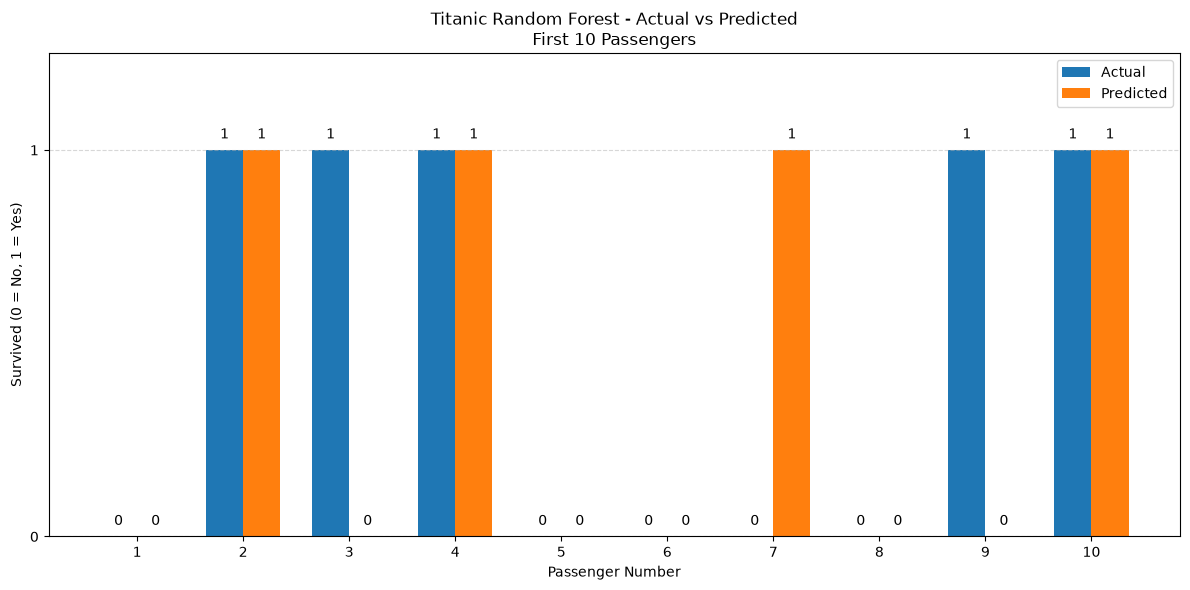

In [11]:
import matplotlib.pyplot as plt
import numpy as np

actual = df["Survived"].iloc[:10].values
predicted = np.array(predictions)

passengers = np.arange(1, 11)

width = 0.35

plt.figure(figsize=(12, 6))

# Actual bars
bars1 = plt.bar(
    passengers - width/2,
    actual,
    width,
    label="Actual"
)

# Predicted bars
bars2 = plt.bar(
    passengers + width/2,
    predicted,
    width,
    label="Predicted"
)

# Add values on top of bars
for bar in bars1:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.03,
        str(int(value)),
        ha="center"
    )

for bar in bars2:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.03,
        str(int(value)),
        ha="center"
    )

# Labels
plt.xlabel("Passenger Number")
plt.ylabel("Survived (0 = No, 1 = Yes)")

plt.title(
    "Titanic Random Forest - Actual vs Predicted\nFirst 10 Passengers"
)

plt.xticks(passengers)

# Give some space above 1
plt.ylim(0, 1.25)

plt.yticks([0, 1])

plt.legend()

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()